## Hotel Reservation Supervised Machine Learning Predictive Model

## Problem Statement:The online hotel reservation channels have dramatically changed booking possibilities and customers’ behavior. A significant number of hotel reservations are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. So, i have to predict if the customer is going to honor the reservation or cancel it ?

In [4]:
import pandas as pd
import numpy as np 
HotelReservationsData=pd.read_csv("C:/Users/abrau/ML Projects/My ML Projects/Classification Projects/Hotel Reservations/Hotel Reservations.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',HotelReservationsData.shape)  
HotelReservationsData.drop_duplicates(inplace=True) 
print('Data After:deleting duplicate values',HotelReservationsData.shape) 
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
HotelReservationsData.head(10) 

Data Before deleting duplicate values: (36275, 19)
Data After:deleting duplicate values (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
5,INN00006,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,2018,9,13,Online,0,0,0,115.00,1,Canceled
6,INN00007,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,2017,10,15,Online,0,0,0,107.55,1,Not_Canceled
7,INN00008,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,2018,12,26,Online,0,0,0,105.61,1,Not_Canceled
8,INN00009,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,2018,7,6,Offline,0,0,0,96.90,1,Not_Canceled
9,INN00010,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,2018,10,18,Online,0,0,0,133.44,3,Not_Canceled


In [5]:
HotelReservationsData.drop('Booking_ID',inplace =True,axis=1) 

In [3]:
HotelReservationsData.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='object')

### Target Variable:price_range

## Exploratory Data Analysis

<Axes: xlabel='booking_status'>

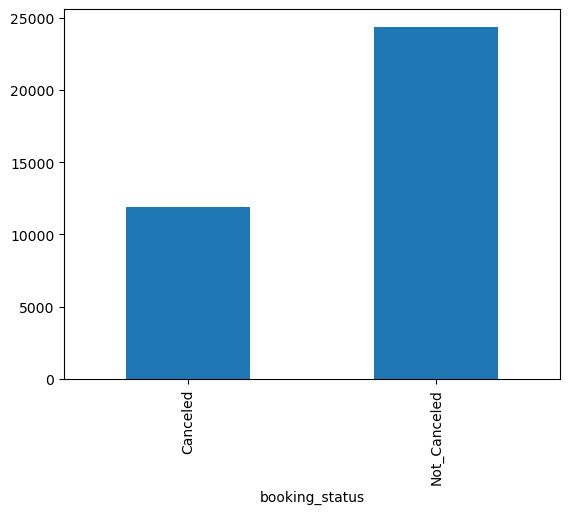

In [4]:
HotelReservationsData.groupby('booking_status').size().plot(kind='bar')

In [5]:
HotelReservationsData.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [10]:
HotelReservationsData.drop(columns='Booking_ID',axis=1,inplace=True)

In [ ]:
HotelReservationsData.columns

In [ ]:
HotelReservationsData.nunique()

In [ ]:
HotelReservationsData

### CategoricalCols=[ 'no_of_adults', 'no_of_children', 'no_of_weekend_nights','type_of_meal_plan', 'required_car_parking_space','room_type_reserved',
### 'arrival_year','arrival_month','arrival_date','market_segment_type', 'repeated_guest','no_of_previous_cancellations','no_of_special_requests']
### ContinousCols=[ 'no_of_week_nights','lead_time','no_of_previous_bookings_not_canceled','avg_price_per_room']

In [ ]:
HotelReservationsData.columns

In [ ]:
HotelReservationsData.info()  

In [ ]:
HotelReservationsData.describe()

## Uni Variate Analysis by Bar Charts

In [ ]:
categorical_Columns=[ 'no_of_adults', 'no_of_children', 'no_of_weekend_nights','type_of_meal_plan', 'required_car_parking_space','room_type_reserved',
'arrival_year','arrival_month','arrival_date','market_segment_type', 'repeated_guest','no_of_previous_cancellations','no_of_special_requests']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(5,3,figsize=(18,25))
subplots=subplots.flatten()
for i,j in zip(categorical_Columns,range(len(categorical_Columns))):
    HotelReservationsData.groupby(i).size().plot(kind='bar',ax=subplots[j])

### No need of imbalance treatment

## Uni Variate Analysis by Histogram

In [ ]:
continousCols=['no_of_week_nights','lead_time','no_of_previous_bookings_not_canceled','avg_price_per_room'] 
HotelReservationsData.hist(continousCols,bins=20,figsize=(15,20))

## Outlier Treatment

## Missing Values Treatment

### No need of missing value treatment

In [ ]:
HotelReservationsData.isnull().sum()

## Continous Vs Categorical Bivariate Analysis by Box Plots

In [ ]:
continousCols=['no_of_week_nights','lead_time','no_of_previous_bookings_not_canceled','avg_price_per_room'] 
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,2,figsize=(15,10)) 
subplots=subplots.flatten() 
for cols, no_of_cols in zip(continousCols,range(len(continousCols))): 
    HotelReservationsData.boxplot(column=cols, by='booking_status', ax=subplots[no_of_cols])

## Statistical Feature Selection by Anova Function

In [ ]:
continousCols=['no_of_week_nights','lead_time','no_of_previous_bookings_not_canceled','avg_price_per_room'] 
SelectedPredictors=[]
from scipy.stats import f_oneway
for cols in continousCols:
    CategoricalGroupLists=HotelReservationsData.groupby('booking_status')[cols].apply(list)
    anovaResults=f_oneway(*CategoricalGroupLists)
    if anovaResults[1]<0.05:
        print(cols,' is correlated with booking_status and p value is:',anovaResults[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with booking_status and p value is:',anovaResults[1])
print(SelectedPredictors)

## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

In [ ]:
categorical_Columns=[ 'no_of_adults', 'no_of_children', 'no_of_weekend_nights','type_of_meal_plan', 'required_car_parking_space','room_type_reserved',
'arrival_year','arrival_month','arrival_date','market_segment_type', 'repeated_guest','no_of_previous_cancellations','no_of_special_requests']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(5,3,figsize=(15,20))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categorical_Columns,range(len(categorical_Columns))):
    crosstabresults=pd.crosstab(columns=HotelReservationsData['booking_status'],index=HotelReservationsData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols]) 
    

## Statistical Feature Selection by Chi2 Function

In [ ]:
categorical_Columns=[ 'no_of_adults', 'no_of_children', 'no_of_weekend_nights','type_of_meal_plan', 'required_car_parking_space','room_type_reserved',
'arrival_year','arrival_month','arrival_date','market_segment_type', 'repeated_guest','no_of_previous_cancellations','no_of_special_requests']
from scipy.stats import chi2_contingency
SelectedPredictors=[]
for cols in categorical_Columns:
    crosstabresults=pd.crosstab(columns=HotelReservationsData['booking_status'],index=HotelReservationsData[cols])
    chi2_results=chi2_contingency(crosstabresults)
    if chi2_results[1]<0.05:
        print(cols,' is correlated with booking status and chi2 value is:',chi2_results[1])
        SelectedPredictors.append(cols)
    else:
        print(cols,' is not correlated with booking status and chi2 value is:',chi2_results[1])
print(SelectedPredictors)

## Selecting final predictors for Machine Learning

In [ ]:
HotelReservationsData.columns

In [6]:
SelectedColumns=['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests']
DataForMLHotelReservationsData=HotelReservationsData[SelectedColumns]
DataForMLHotelReservationsData.to_pickle('DataForMLHotelReservationsData.pkl')
DataForMLHotelReservationsData=pd.read_pickle('DataForMLHotelReservationsData.pkl')

## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [7]:
DataForMLHotelReservationsData_Numeric=pd.get_dummies(DataForMLHotelReservationsData)
DataForMLHotelReservationsData_Numeric.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True


## Converting the binary nominal variable to numeric using 1/0 mapping

In [8]:
DataForMLHotelReservationsData_Numeric.replace({False:0,True:1},inplace=True)

C:\Users\abrau\AppData\Local\Temp\ipykernel_113748\3447977585.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataForMLHotelReservationsData_Numeric.replace({False:0,True:1},inplace=True)


In [ ]:
DataForMLHotelReservationsData_Numeric.columns

In [9]:
DataForMLHotelReservationsData_Numeric['booking_status']=HotelReservationsData['booking_status'] 

In [10]:
DataForMLHotelReservationsData_Numeric['booking_status'].replace({'Canceled':0,'Not_Canceled':1},inplace=True) 

C:\Users\abrau\AppData\Local\Temp\ipykernel_113748\1925382458.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  DataForMLHotelReservationsData_Numeric['booking_status'].replace({'Canceled':0,'Not_Canceled':1},inplace=True)
C:\Users\abrau\AppData\Local\Temp\ipykernel_113748\1925382458.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('f

In [11]:
DataForMLHotelReservationsData_Numeric.head(10) 

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0
5,2,0,0,2,0,346,2018,9,13,0,0,0,115.00,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
6,2,0,1,3,0,34,2017,10,15,0,0,0,107.55,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
7,2,0,1,3,0,83,2018,12,26,0,0,0,105.61,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1
8,3,0,0,4,0,121,2018,7,6,0,0,0,96.90,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
9,2,0,0,5,0,44,2018,10,18,0,0,0,133.44,3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1


## Splitting the data into Training and Testing sample

In [34]:
DataForMLHotelReservationsData_Numeric.shape

(2000, 21)

In [29]:
DataForMLHotelReservationsData_Numeric.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,Not_Canceled
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,Not_Canceled
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,Canceled
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,Canceled
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,Canceled


In [81]:
DataForMLHotelReservationsData_Numeric.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online',
       'booking_status'],
      dtype='object')

In [13]:
predictors=['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 1', 'type_of_meal_plan_Meal Plan 2',
       'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected',
       'room_type_reserved_Room_Type 1', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Aviation',
       'market_segment_type_Complementary', 'market_segment_type_Corporate',
       'market_segment_type_Offline', 'market_segment_type_Online']
targetVariable='booking_status'
X=DataForMLHotelReservationsData_Numeric[predictors].values 
y=DataForMLHotelReservationsData_Numeric[targetVariable].values 
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=5) 

In [18]:
X_train[0:5]

array([[3.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 5.000e+00,
        2.018e+03, 5.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.770e+02, 2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00],
       [2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.500e+01,
        2.018e+03, 1.200e+01, 1.500e+01, 1.000e+00, 1.000e+00, 5.000e+00,
        1.090e+02, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00],
       [2.000e+00, 0.000e+00, 2.000e+00, 6.000e+00, 0.000e+00, 4.400e+01,
        2.018e+03, 3.000e+00, 4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        5.995e+01, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e

In [19]:
y_train[0:5]

array([1, 1, 1, 0, 0])

## Logistic Regression

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train) 
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction)) 
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2)*100,'%')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')
mse = metrics.mean_squared_error(y_test, prediction)
print("Mean Squared Error:", mse)

rmse = mse ** 0.5
print("Root Mean Squared Error:", rmse)

mae = metrics.mean_absolute_error(y_test, prediction)
print("Mean Absolute Error:", mae)


              precision    recall  f1-score   support

           0       0.71      0.62      0.66      2297
           1       0.83      0.88      0.86      4958

    accuracy                           0.80      7255
   macro avg       0.77      0.75      0.76      7255
weighted avg       0.79      0.80      0.79      7255

[[1414  883]
 [ 582 4376]]
Sample Data Accuracy: 79.0 %
[0.82333807 0.79680912 0.78522276 0.7897289  0.79190256]
Final Accuracy of the Model: 80.0 %
Mean Squared Error: 0.20192970365265334
Root Mean Squared Error: 0.44936589061994164
Mean Absolute Error: 0.20192970365265334


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(max_depth =2,citerion='entropy')

              precision    recall  f1-score   support

           0       0.63      0.71      0.67      2297
           1       0.86      0.81      0.83      4958

    accuracy                           0.78      7255
   macro avg       0.75      0.76      0.75      7255
weighted avg       0.79      0.78      0.78      7255

[[1637  660]
 [ 944 4014]]
Sample Data Accuaracy: 78.0 %
[0.81368982 0.78884121 0.77923797 0.78281641 0.78159348]
Final Accuracy of the Model: 79.0 %
Mean Squared Error: 0.22108890420399724
Root Mean Squared Error: 0.47020091897400335
Mean Absolute Error: 0.22108890420399724


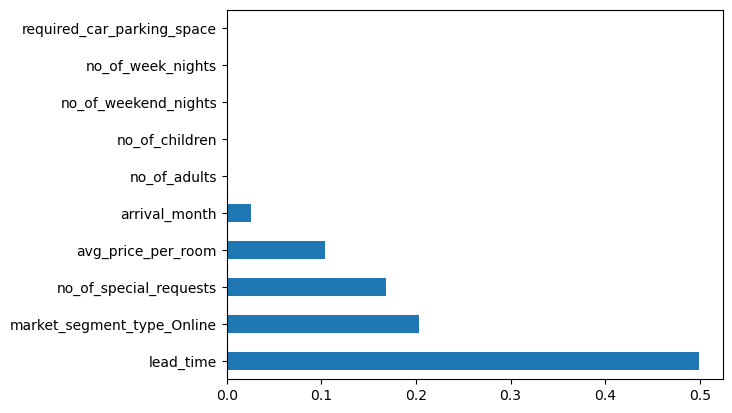

In [36]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2)*100,'%')
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')
mse = metrics.mean_squared_error(y_test, prediction)
print("Mean Squared Error:", mse)

rmse = mse ** 0.5
print("Root Mean Squared Error:", rmse)

mae = metrics.mean_absolute_error(y_test, prediction)
print("Mean Absolute Error:", mae)

## Random Forest Classifier

In [28]:
import matplotlib.pyplot as plt

RandomForestClassifier(oob_score=True)
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      2297
           1       0.92      0.94      0.93      4958

    accuracy                           0.90      7255
   macro avg       0.90      0.88      0.89      7255
weighted avg       0.90      0.90      0.90      7255

[[1878  419]
 [ 275 4683]]
OOB Score: 90.0 %
OOB Error: 10.0 %
ROC-AUC Score: 0.9562


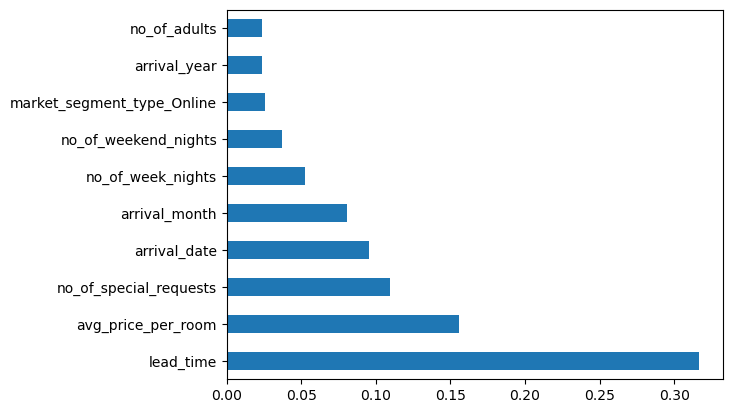

In [16]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100,criterion='gini', oob_score=True)
print(clf)
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score

y_prob = RF.predict_proba(X_test)[:, 1]



#auc = roc_auc_score(y_test, y_prob)

#fpr, tpr, _ = roc_curve(y_test, y_prob)

#plt.figure(figsize=(7,5))
#plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
#plt.plot([0,1], [0,1], '--')
#plt.xlabel("False Positive Rate")
#plt.ylabel("True Positive Rate")
#plt.title("ROC Curve")
#plt.legend()
#plt.grid(True)
#plt.show()


OOBScore = RF.oob_score_

print("OOB Score:", round(OOBScore,2)*100,'%')

OOBError = 1 - OOBScore

print("OOB Error:", round(OOBError,2)*100,'%')


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))

In [30]:
#!pip install xgboost

In [31]:
#import sys
#!{sys.executable} -m pip install xgboost

In [32]:
#from xgboost import XGBClassifier

#print("XGBoost installed successfully!")

In [33]:
#import sys
#print(sys.executable) 

In [34]:
#import sys
#!{sys.executable} -m pip show xgboost

In [35]:
#import sys
#print(sys.executable)

#!{sys.executable} -m pip list

## XGBoost Classifier

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, ...)
0.10130944176430048
0.10130944176430048
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      2297
           1       0.92      0.93      0.93      4958

    accuracy                        

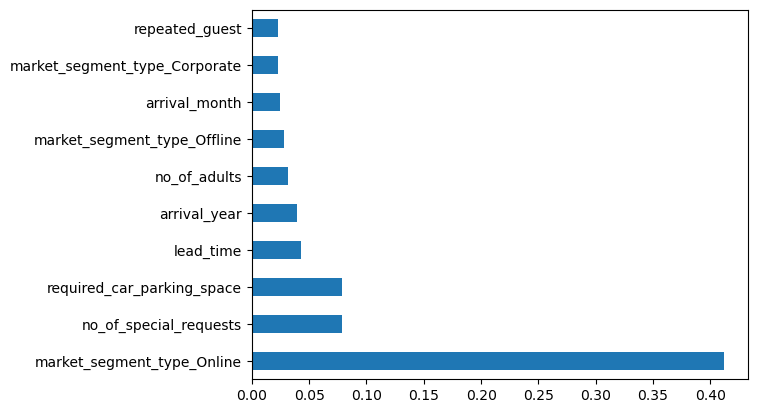

In [25]:
###### Xgboost Classification in Python #######

from sklearn.metrics  import  mean_squared_error,mean_absolute_error
import pandas as pd 
from xgboost import XGBClassifier 
clf=XGBClassifier(max_depth=7, learning_rate=0.1, n_estimators=700, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)


#Creating the model on Training Data                                                                                                         
XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)

mse=mean_squared_error(y_test,prediction)
print(mse)
mae=mean_absolute_error(y_test,prediction)
print(mae)
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))

print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh') 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction   
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")
mse = metrics.mean_squared_error(y_test, prediction)
print("Mean Squared Error:", mse)
rmse = mse ** 0.5
print("Root Mean Squared Error:", rmse)
mae = metrics.mean_absolute_error(y_test, prediction)
print("Mean Absolute Error:", mae)

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=0.1, n_estimators=100)
              precision    recall  f1-score   support

           0       0.79      0.62      0.70      2297
           1       0.84      0.92      0.88      4958

    accuracy                           0.83      7255
   macro avg       0.81      0.77      0.79      7255
weighted avg       0.82      0.83      0.82      7255

[[1435  862]
 [ 390 4568]]


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,TargetColumn,Prediction
0,1.0,0.0,1.0,0.0,0.0,39.0,2018.0,9.0,25.0,0.0,0.0,0.0,129.70,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0
1,2.0,0.0,1.0,3.0,0.0,21.0,2018.0,12.0,1.0,0.0,0.0,0.0,122.19,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1
2,1.0,0.0,0.0,3.0,0.0,29.0,2018.0,5.0,17.0,0.0,0.0,0.0,90.00,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
3,1.0,0.0,0.0,2.0,0.0,74.0,2017.0,9.0,18.0,0.0,0.0,0.0,87.00,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1,1
4,2.0,0.0,0.0,0.0,0.0,22.0,2018.0,7.0,27.0,0.0,0.0,0.0,0.00,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1


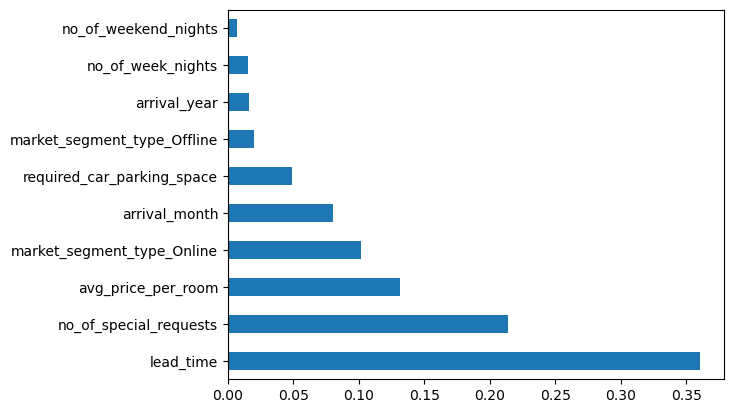

In [19]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=3)
clf = AdaBoostClassifier(n_estimators=100, estimator=DTC ,learning_rate=0.1)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()

In [38]:
import sys
print(sys.executable)

C:\ProgramData\anaconda3\python.exe


In [39]:
import sys
!{sys.executable} -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [40]:
import sys
print(sys.executable)
!where python
!pip show xgboost

C:\ProgramData\anaconda3\python.exe
C:\ProgramData\anaconda3\python.exe
C:\Users\abrau\AppData\Local\Microsoft\WindowsApps\python.exe
Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: C:\Users\abrau\AppData\Roaming\Python\Python313\site-packages
Requires: numpy, scipy
Required-by: 


# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [26]:

NewData=pd.DataFrame(data= [
    [2, 0, 1, 2, 0, 224, 2017, 10, 2, 0, 0, 0, 65.00, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],

    [2, 0, 2, 3, 0, 5, 2018, 11, 6, 0, 0, 0, 106.68, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],

    [1, 0, 2, 1, 0, 1, 2018, 2, 28, 0, 0, 0, 60.00, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],

    [2, 0, 0, 2, 0, 211, 2018, 5, 20, 0, 0, 0, 100.00, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],

    [2, 0, 1, 1, 0, 48, 2018, 4, 11, 0, 0, 0, 94.50, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
]	,columns=predictors)
NewData

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1


In [27]:
newX=NewData.values

In [28]:
XGB.predict(newX)

array([1, 1, 0, 0, 0])

In [29]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [30]:
GenerateSurvialPred(inpData=NewData)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 1,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 1,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,Prediction
0,2,0,1,2,0,224,2017,10,2,0,0,0,65.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1
1,2,0,2,3,0,5,2018,11,6,0,0,0,106.68,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1
2,1,0,2,1,0,1,2018,2,28,0,0,0,60.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
3,2,0,0,2,0,211,2018,5,20,0,0,0,100.00,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
4,2,0,1,1,0,48,2018,4,11,0,0,0,94.50,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0


https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset